# CS235 Fall 2025 Course Project

Names: Shahd Elmahallawy - Nishant Tiwari

Student ID: 862621311 - 862302877

## Introduction
In this project, a number of data mining techniques that we cover in this class will be implemented and applied to a real-world imbalanced
dataset.

**Dataset:** Wisconsin Breast Cancer Diagnostic dataset from the UCI data repository: https://archive.ics.uci.edu/dataset/17/breast+cancer+wisconsin+diagnostic

## Setup

1. Create new python environment for the project

- This is not necessary on Google Colab but a good practice on your local machine

2. Install the required packages

In [ ]:
!pip install ucimlrepo

## Imports

In [ ]:
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns
import itertools, collections
import numpy as np
import pandas as pd

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score
from ucimlrepo import fetch_ucirepo
from sklearn.neighbors import NearestNeighbors

## Load Data

In [ ]:
# Fetch dataset
breast_cancer_wisconsin_diagnostic = fetch_ucirepo(id=17)

# Data (as pandas dataframes)
X = breast_cancer_wisconsin_diagnostic.data.features
y = breast_cancer_wisconsin_diagnostic.data.targets

# Metadata
print(breast_cancer_wisconsin_diagnostic.metadata)

X

{'uci_id': 17, 'name': 'Breast Cancer Wisconsin (Diagnostic)', 'repository_url': 'https://archive.ics.uci.edu/dataset/17/breast+cancer+wisconsin+diagnostic', 'data_url': 'https://archive.ics.uci.edu/static/public/17/data.csv', 'abstract': 'Diagnostic Wisconsin Breast Cancer Database.', 'area': 'Health and Medicine', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 569, 'num_features': 30, 'feature_types': ['Real'], 'demographics': [], 'target_col': ['Diagnosis'], 'index_col': ['ID'], 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 1993, 'last_updated': 'Fri Nov 03 2023', 'dataset_doi': '10.24432/C5DW2B', 'creators': ['William Wolberg', 'Olvi Mangasarian', 'Nick Street', 'W. Street'], 'intro_paper': {'ID': 230, 'type': 'NATIVE', 'title': 'Nuclear feature extraction for breast tumor diagnosis', 'authors': 'W. Street, W. Wolberg, O. Mangasarian', 'venue': 'Electronic imaging', 'year': 1993, 'journal': None, 'DOI': '1

,radius1,texture1,perimeter1,area1,smoothness1,compactness1,concavity1,concave_points1,symmetry1,fractal_dimension1,...,radius3,texture3,perimeter3,area3,smoothness3,compactness3,concavity3,concave_points3,symmetry3,fractal_dimension3
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,0.07871,...,25.380,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,0.05667,...,24.990,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,0.05999,...,23.570,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,0.09744,...,14.910,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,0.05883,...,22.540,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,0.05623,...,25.450,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115
565,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,0.05533,...,23.690,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637
566,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,0.05648,...,18.980,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820
567,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,0.07016,...,25.740,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400


## Exploratory Data Analysis (EDA)

### Pairwise correlation between features

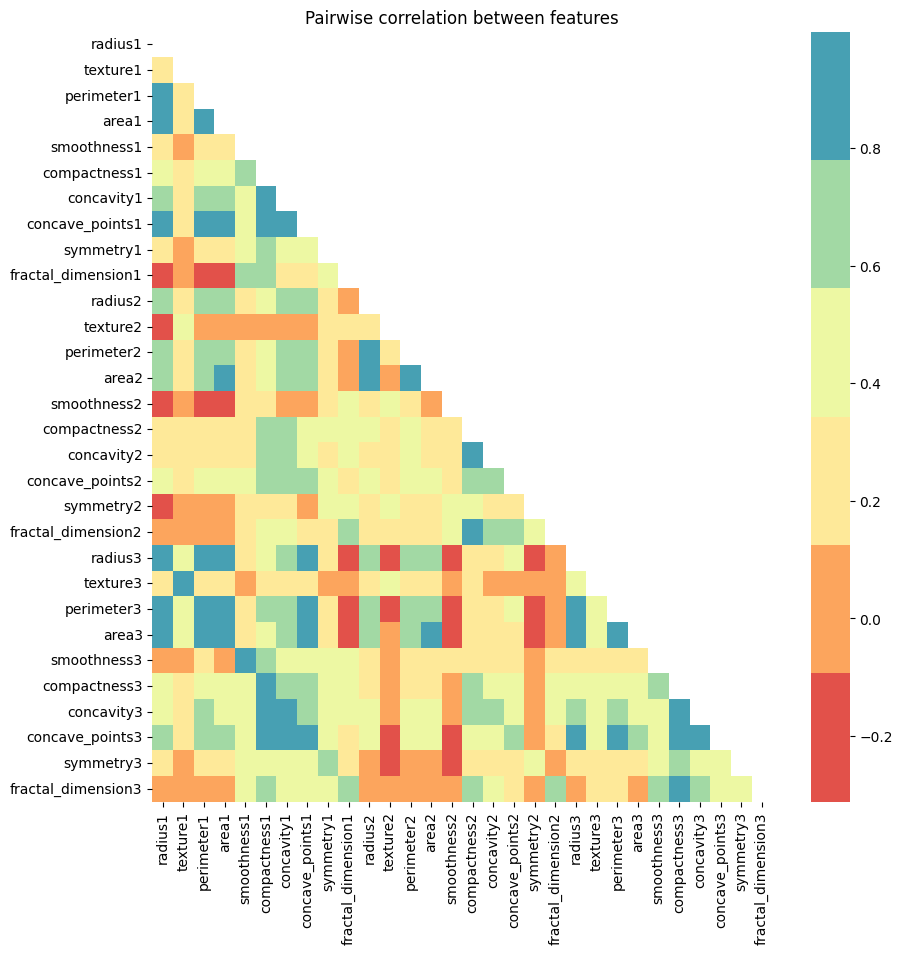

In [ ]:
correlation = X.corr()

fig, ax = plt.subplots(1,1, figsize=(10,10))
sns.heatmap(correlation, annot=False, mask=np.triu(correlation),
            cmap=sns.color_palette("Spectral"))
ax.set_title("Pairwise correlation between features")
plt.show()

### Class Counts

In [ ]:
print(collections.Counter(y['Diagnosis']))

Counter({'B': 357, 'M': 212})


### Class-wise features distributions

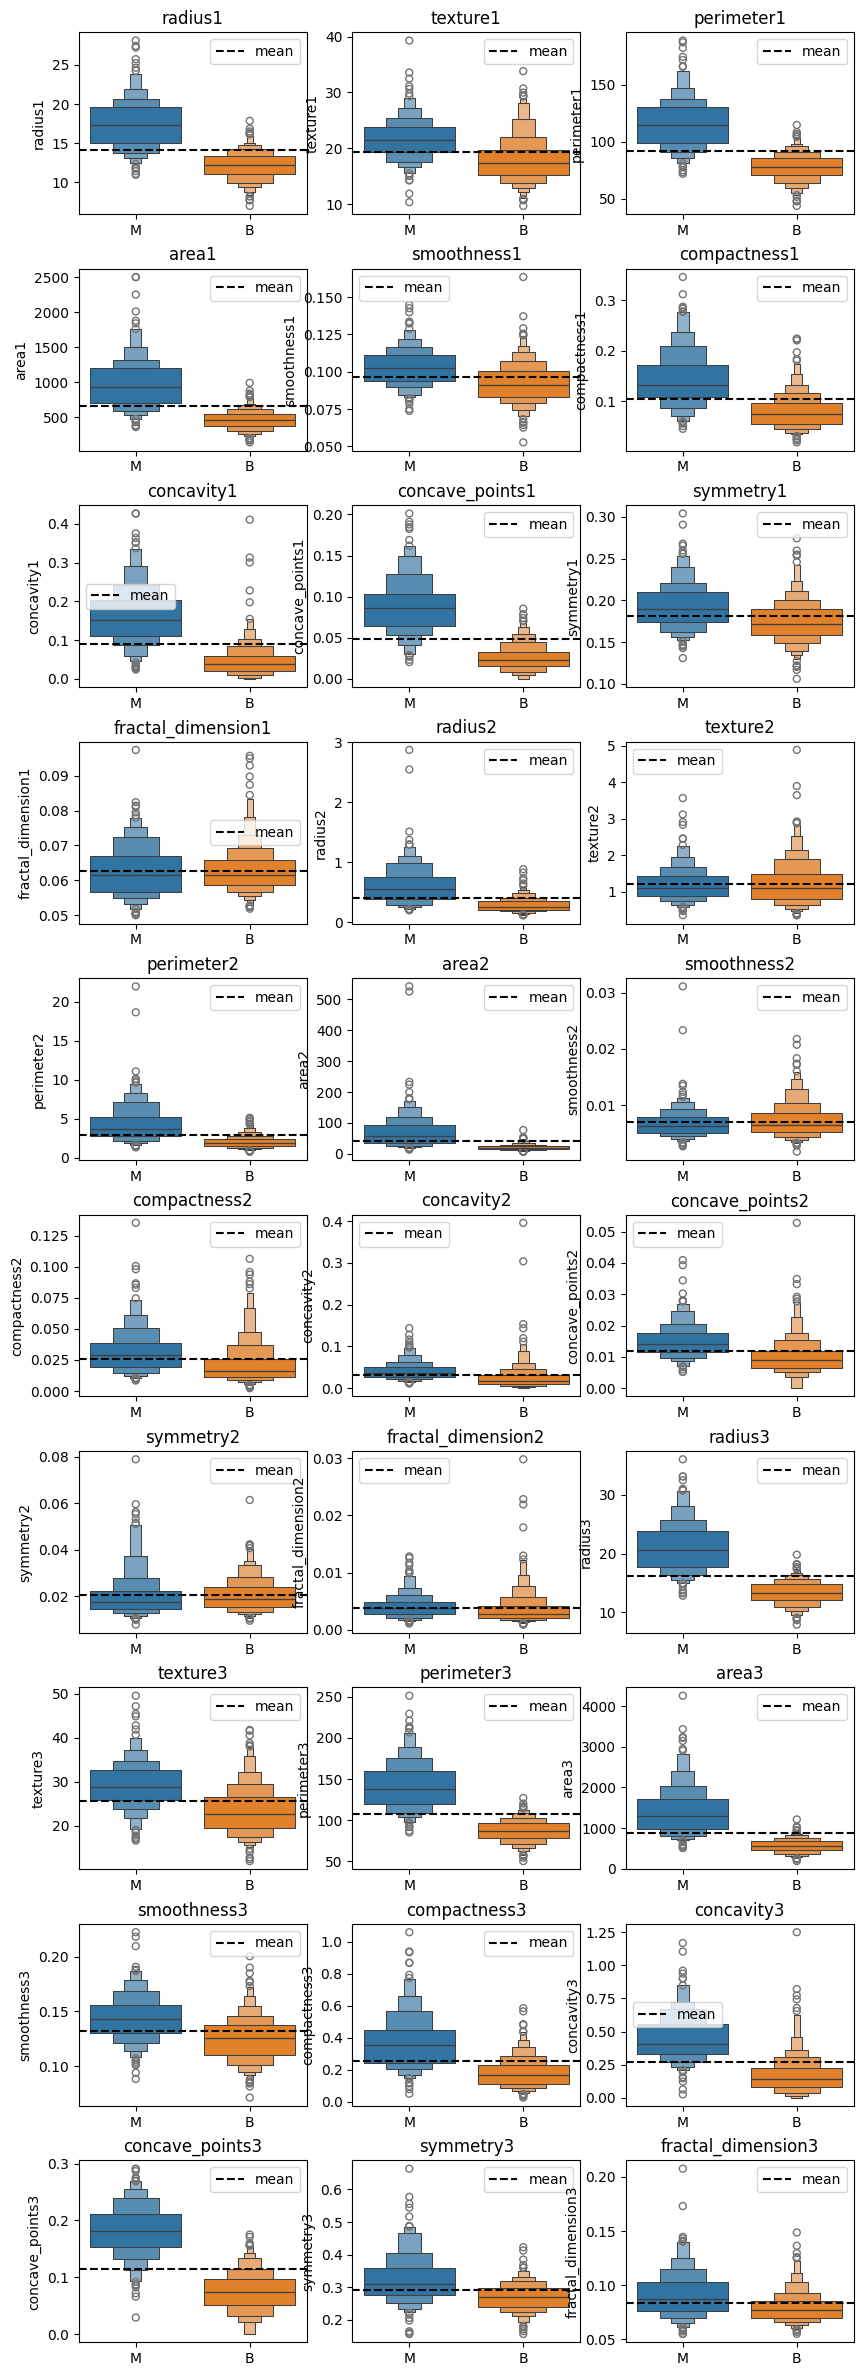

In [ ]:
plt.figure(figsize=(10,30))

for i,j in itertools.zip_longest(list(X.columns), range(len(list(X.columns)))):
  plt.subplot(10,3,j+1)
  sns.boxenplot(x=y['Diagnosis'], y=X[i], hue=y['Diagnosis'])
  plt.title(i)
  plt.xlabel('')
  plt.subplots_adjust(hspace=.3)
  plt.axhline(X[i].mean(), linestyle="dashed", color='k', label='mean')
  plt.legend(loc='best')

# Phase 1 - Supervised Techniques

## Q1 - Implementing simple classifiers

Decision Tree Classifier:


*   Implemented a Decision Tree Classifier from scratch using Information Gain (entropy) as the splitting criterion.
*  The tree is built recursively by evaluating all features and thresholds to find the split with the highest information gain.
*   Stopping conditions include reaching maximum depth, having too few samples, or all labels being identical.
*   Leaf nodes predict the majority class.
*   The model was evaluated using 10-fold stratified cross-validation with F1 score, and results were visualized with a bar chart showing mean ± standard deviation.



Bayes Classfier:

* Implemented a Gaussian Naive Bayes classifer from scratch where for each class I calculated per feature mean, variance and class priors (how common the class is in dataset)
* Assumed the feature independence given the class and gaussian likelihoods for continuous features.
* To avoid numerical issues, I added small e to variance for stablity, and used log spcae to keep math stable instead of reling on raw probabilities
* My prediciton relied on class with highest log posterior value.
* Also implemented fit() which computes and stores the stats I discussed.
* I also added get_params/set_params so scikit-learn can clone a fresh model per CV fold and this specific is implemented in feature selection.
* At the end, I did my evaluation by using 10 fold stratified cross validation with F1 scores and displayed the mean and standard dev on chart.











### Decision Tree

In [ ]:
#helper function for entropy and information gain
def entropy(y):
    """Compute entropy of a label distribution."""
    values, counts = np.unique(y, return_counts=True) # Count how many samples belong to each class
    probs = counts / counts.sum() # Convert counts to probabilities
    return -np.sum(probs * np.log2(probs + 1e-9)) # Compute entropy using base-2 logarithm

def information_gain(X_col, y, threshold):
    """Compute the information gain of a split on a given threshold."""
    parent_entropy = entropy(y)

    left_mask = X_col <= threshold
    right_mask = X_col > threshold
    n = len(y)
    if np.sum(left_mask) == 0 or np.sum(right_mask) == 0: # If either split is empty, IG = 0
        return 0  # invalid split

    left_entropy = entropy(y[left_mask])
    right_entropy = entropy(y[right_mask])

    child_entropy = (np.sum(left_mask)/n) * left_entropy + (np.sum(right_mask)/n) * right_entropy
    ig = parent_entropy - child_entropy
    return ig


In [ ]:
#Simple Decision Tree Node Class
class DecisionTreeNode:
    """
    Represents a single node in the Decision Tree.
    Each node may either be:
        - An internal (split) node: stores feature index & threshold.
        - A leaf node: stores a predicted class label (value).
    """
    def __init__(self, feature_index=None, threshold=None, left=None, right=None, value=None):
        self.feature_index = feature_index
        self.threshold = threshold
        self.left = left
        self.right = right
        self.value = value

#Recursive Tree Builder
class DecisionTreeClassifierIG:
    """
    Decision Tree Classifier using Information Gain (Entropy)
    """
    def __init__(self, max_depth=5, min_samples_split=2):
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.root = None

    def fit(self, X, y):
        self.root = self._build_tree(X, y, depth=0)

    def get_params(self, deep=False): # added by Nishant
        return {"max_depth": self.max_depth, "min_samples_split": self.min_samples_split}

    def set_params(self, **parameters): # added by Nishant
        for parameter, value in parameters.items():
            setattr(self, parameter, value)
            return self

    def _build_tree(self, X, y, depth):
        n_samples, n_features = X.shape
        unique_labels = np.unique(y)

        # Stopping conditions
        if (len(unique_labels) == 1 or
            depth >= self.max_depth or
            n_samples < self.min_samples_split):
            leaf_value = self._majority_vote(y)
            return DecisionTreeNode(value=leaf_value)

        # Find best split
        best_feature, best_threshold, best_ig = None, None, -1
        for feature_index in range(n_features):
            thresholds = np.unique(X[:, feature_index])
            for t in thresholds:
                ig = information_gain(X[:, feature_index], y, t)
                if ig > best_ig:
                    best_feature, best_threshold, best_ig = feature_index, t, ig

        if best_ig == 0:
            return DecisionTreeNode(value=self._majority_vote(y))

        # Split recursively
        left_mask = X[:, best_feature] <= best_threshold
        right_mask = X[:, best_feature] > best_threshold

        left_child = self._build_tree(X[left_mask], y[left_mask], depth+1)
        right_child = self._build_tree(X[right_mask], y[right_mask], depth+1)

        return DecisionTreeNode(feature_index=best_feature, threshold=best_threshold,
                                left=left_child, right=right_child)

    def _majority_vote(self, y):
        """
        Return the most common class label in y.
        Used for assigning labels to leaf nodes.
        """
        values, counts = np.unique(y, return_counts=True)
        return values[np.argmax(counts)]

    def predict_one(self, x, node):
        """
        Predict class for a single data point by traversing the tree recursively.
        """
        if node.value is not None:
            return node.value
        if x[node.feature_index] <= node.threshold:
            return self.predict_one(x, node.left)
        else:
            return self.predict_one(x, node.right)

    def predict(self, X):
        """
        Predict labels for all samples in X.
        """
        return np.array([self.predict_one(sample, self.root) for sample in X])

In [ ]:
# Standardize features
X_tree = StandardScaler().fit_transform(X)
y_tree = y['Diagnosis'].map({'M': 1, 'B': 0}).values

# Stratified 10-fold CV setup
kf_tree = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
tree_f1_scores = []

# Cross-validation loop
for train_idx, test_idx in kf_tree.split(X_tree, y_tree):
    tree_model = DecisionTreeClassifierIG(max_depth=4)
    tree_model.fit(X_tree[train_idx], y_tree[train_idx])
    preds_tree = tree_model.predict(X_tree[test_idx])
    f1_tree = f1_score(y_tree[test_idx], preds_tree)
    tree_f1_scores.append(f1_tree)

# Aggregate results
tree_f1_mean = np.mean(tree_f1_scores)
tree_f1_std  = np.std(tree_f1_scores)

print(f"Decision Tree F1 (mean ± std): {tree_f1_mean:.4f} ± {tree_f1_std:.4f}")

Decision Tree F1 (mean ± std): 0.8927 ± 0.0453


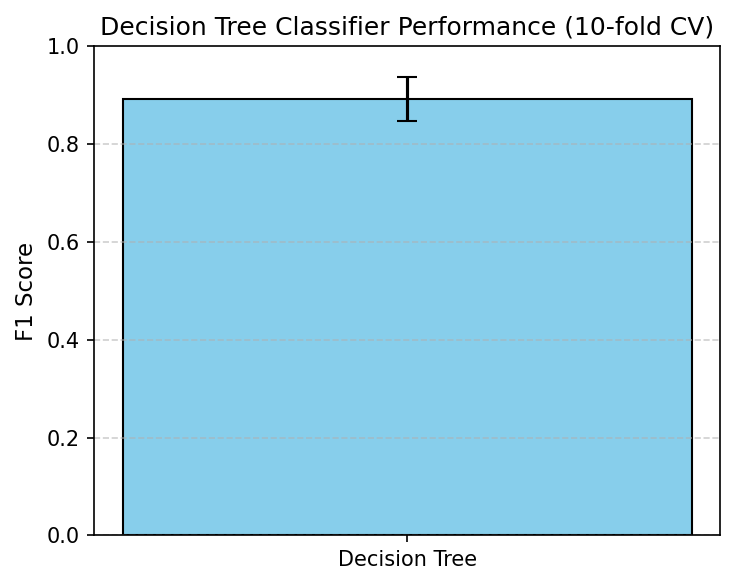

In [ ]:
#Plot Decision Tree Classifier Performance (10-Fold CV)
models_tree = ['Decision Tree']
scores_mean_tree = [tree_f1_mean]
scores_std_tree = [tree_f1_std]

plt.figure(figsize=(5,4), dpi=150)
plt.bar(models_tree, scores_mean_tree, yerr=scores_std_tree,
        color='skyblue', capsize=5, edgecolor='black')

plt.ylabel('F1 Score', fontsize=11)
plt.title('Decision Tree Classifier Performance (10-fold CV)', fontsize=12)
plt.ylim(0, 1)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

### Bayes

In [ ]:
# Bayes classifier using Gaussian modeling

class GaussianNaiveBayes:

  # storing class labels, means, variance and class priors
  def __init__(self):
    self.classes = None
    self.means = None
    self.variance = None
    self.priors = None
    pass

  def get_params(self, deep = False):
    return {}

  def set_params(self, **parameters):
    return self

  def fit(self, X, y):
    X = np.array(X)
    y = np.array(y)

    # saving the uniques class: benign and malignant
    self.classes = np.unique(y)

    n_features = X.shape[1]

    n_classes = len(self.classes)

    # to store the compututated mean, variance and priors

    self.means = np.zeros((n_classes, n_features))
    self.variance = np.zeros((n_classes, n_features))
    self.priors = np.zeros(n_classes)

    # calculating the math:

    for i in range(n_classes):
      label = self.classes[i]
      X_label = X[y == label]

      self.means[i] = X_label.mean(axis=0)
      self.variance[i] = X_label.var(axis=0) + 1e-6
      self.priors[i] = X_label.shape[0] / float(X.shape[0])

  # Gaussian log probability helper
  def log_probability(self, x, mean, var):
    return -0.5 * (np.log(2 * np.pi * var) + ((x - mean) ** 2) / var)

  def predict(self, X):
    X = np.array(X)
    predictions = [] # to store predicted labels

    for x in X:
      posteriors = [] # to store probability score for each class

      # looping over class 0 to 1

      for i in range(len(self.classes)):
        label = self.classes[i]
        prior = np.log(self.priors[i])
        log_likehood = np.sum(self.log_probability(x, self.means[i], self.variance[i]))
        posterior = prior + log_likehood
        posteriors.append(posterior)

      # choosing the highest prob
      best_index = np.argmax(posteriors)
      chosen_class = self.classes[best_index]
      predictions.append(chosen_class)

    return np.array(predictions)


# https://www.geeksforgeeks.org/machine-learning/gaussian-naive-bayes/ - used this to get the rough understanding of algorithm esp. gaussian formula with conditional independence
# https://scikit-learn.org/stable/modules/naive_bayes.html  - used this link for understanding the skeleton of gaussian naibe bayes such as seeing how priors and gaussian likelihood works



In [ ]:
# 10 fold cross validation for Naive Bayes -

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score
from sklearn.preprocessing import StandardScaler

# K 10 folds for cross validation

X_np = np.array(X)
y_np = np.array(y).flatten()

naive_bayes_score = [] # to store the f1 scores


k_fold = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

for train_index, test_index in k_fold.split(X_np, y_np):
  X_train, X_test = X_np[train_index], X_np[test_index]
  y_train, y_test = y_np[train_index], y_np[test_index]

  # standard scaling ensuring all the features are on same scale

  scaler = StandardScaler()
  X_train = scaler.fit_transform(X_train)
  X_test = scaler.transform(X_test)

  # training the model

  naive_bayes = GaussianNaiveBayes()
  naive_bayes.fit(X_train, y_train)

  # predicting

  y_pred = naive_bayes.predict(X_test)

  # calculating the f1 score

  f1 = f1_score(y_test, y_pred, average='weighted')
  naive_bayes_score.append(f1)

  #printing
print("F1 Score:", f1)

# https://www.geeksforgeeks.org/machine-learning/cross-validation-machine-learning/


F1 Score: 0.982050841635177


Mean Naive Bayes F1 Score: 0.9311
Standard Deviation: 0.0311


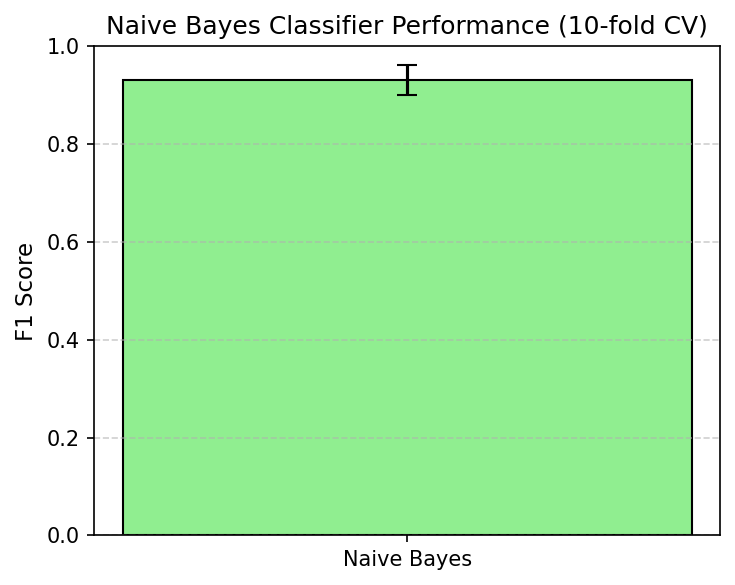

In [ ]:
# Compute mean and standard deviation
mean_naive_bayes = np.mean(naive_bayes_score)
stddev_naive_bayes = np.std(naive_bayes_score)

print(f"Mean Naive Bayes F1 Score: {mean_naive_bayes:.4f}")
print(f"Standard Deviation: {stddev_naive_bayes:.4f}")

# Create bar plot
plt.figure(figsize=(5, 4), dpi=150)
plt.bar(['Naive Bayes'], [mean_naive_bayes],
        yerr=[stddev_naive_bayes],
        color='lightgreen', edgecolor='black', capsize=5)

# Formatting
plt.ylabel('F1 Score', fontsize=11)
plt.title('Naive Bayes Classifier Performance (10-fold CV)', fontsize=12)
plt.ylim(0, 1)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


### Final Plottig

This figure below compares the average F1 scores (10-fold stratified cross-validation) of the two implemented classifiers: Decision Tree and Naive Bayes. Each bar represents the mean F1 score, and the error bars indicate the standard deviation across folds.

The Naive Bayes classifier achieved a slightly higher mean F1 score (0.931) compared to the Decision Tree (0.893), showing more consistent and robust performance across folds. This result is expected because Naive Bayes assumes feature independence and performs well on this dataset, where many features are moderately correlated but still provide strong individual signals. In contrast, the Decision Tree, although interpretable, can be more sensitive to small variations and overfitting in limited data.

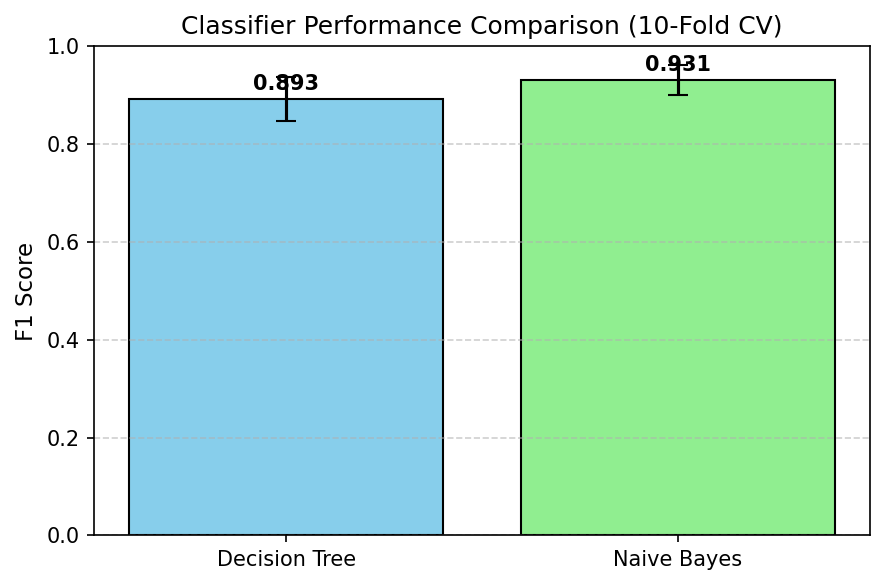

In [ ]:
# Mean and Std from previous evaluations
models = ['Decision Tree', 'Naive Bayes']
scores_mean = [tree_f1_mean, mean_naive_bayes]
scores_std = [tree_f1_std, stddev_naive_bayes]

# Create bar plot
plt.figure(figsize=(6, 4), dpi=150)
bars = plt.bar(models, scores_mean, yerr=scores_std,
               color=['skyblue', 'lightgreen'],
               edgecolor='black', capsize=5)

# Add labels on top of each bar
for bar, mean in zip(bars, scores_mean):
    plt.text(bar.get_x() + bar.get_width()/2, mean + 0.01,
             f"{mean:.3f}", ha='center', va='bottom', fontsize=10, fontweight='bold')

# Formatting
plt.ylabel('F1 Score', fontsize=11)
plt.title('Classifier Performance Comparison (10-Fold CV)', fontsize=12)
plt.ylim(0, 1)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

## Q2 - Dimensionality reduction with the Singular Value Decomposition

* In SVD, as per given instructions, I applied SVD on train split only to avoid leakage.
* factor the training matrix as X_train = U S V^T, keep the top-k rows of V^T (strongest feature directions), and projected both train and test onto these directions. This reduces features from d to k and avoids leakage because the directions are learned on the train split only.
* standardized inside each fold (fit StandardScaler on train, transform test), then train the given model on the k dimensional features.
* ran 10-fold stratified CV for each k in k_list, compute F1 (weighted), and record mean and std.
* Then plotted the performace vs rank with error bars to display how dimensionality affects the classifier.
After analyzing the results, in terms of model, decision tree is performing better.

In [ ]:
## SVD

from sklearn.metrics import f1_score
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold

def svd_dimensionality(model, X, y, k_list):

    X_np = np.array(X)
    y_np = np.array(y).flatten()


    sdv_sf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

    mean_scores = []

    std_dev_scores = []

    # loop over diff k values
    for k in k_list:
      scores = []

      for train_index, test_index in sdv_sf.split(X_np, y_np):
        X_train, X_test = X_np[train_index], X_np[test_index]
        y_train, y_test = y_np[train_index], y_np[test_index]

        # standardizing

        scaler = StandardScaler()
        X_train = scaler.fit_transform(X_train)
        X_test = scaler.transform(X_test)

        # computing the svd on training

        U, S, Vt = np.linalg.svd(X_train, full_matrices=False)

        X_train_k = X_train @ Vt[:k, :].T
        X_test_k = X_test @ Vt[:k, :].T

        # training the model
        model.fit(X_train_k, y_train)
        y_pred = model.predict(X_test_k)

        # calculating the f1 score
        scores.append(f1_score(y_test, y_pred, average='weighted'))

      mean_scores.append(np.mean(scores))
      std_dev_scores.append(np.std(scores))


      print(f"K = {k}, Mean F1 Score = {np.mean(scores):.4f}, Std Dev of F1 score = {np.std(scores):.4f}")


    return mean_scores, std_dev_scores



 #  https://codesignal.com/learn/courses/eigenvalues-eigenvectors-and-diagonalization-with-numpy/lessons/singular-value-decomposition-svd-with-numpy : used this for reference
# https://numpy.org/doc/2.3/reference/generated/numpy.linalg.svd.html I used to get theoretical knowledge of how can i do the split to prevent any data leakage and at same time keeping top k vectors.



In [ ]:
# SVD

# defining the k list

print ('Bayes K values')

k_list = [2, 5, 10, 12, 15, 20, 25, 30]

nb_mean, nb_std = svd_dimensionality(naive_bayes, X, y, k_list)

print('Decision Tree K values')

# call the decision tree here
dt = DecisionTreeClassifierIG(max_depth=4, min_samples_split = 2)
dt_mean, dt_std = svd_dimensionality(dt, X, y, k_list)



Bayes K values
K = 2, Mean F1 Score = 0.9097, Std Dev of F1 score = 0.0387
K = 5, Mean F1 Score = 0.9239, Std Dev of F1 score = 0.0304
K = 10, Mean F1 Score = 0.9166, Std Dev of F1 score = 0.0413
K = 12, Mean F1 Score = 0.9128, Std Dev of F1 score = 0.0404
K = 15, Mean F1 Score = 0.8970, Std Dev of F1 score = 0.0416
K = 20, Mean F1 Score = 0.8756, Std Dev of F1 score = 0.0515
K = 25, Mean F1 Score = 0.8477, Std Dev of F1 score = 0.0421
K = 30, Mean F1 Score = 0.8527, Std Dev of F1 score = 0.0367
Decision Tree K values
K = 2, Mean F1 Score = 0.9220, Std Dev of F1 score = 0.0408
K = 5, Mean F1 Score = 0.9436, Std Dev of F1 score = 0.0259
K = 10, Mean F1 Score = 0.9435, Std Dev of F1 score = 0.0314
K = 12, Mean F1 Score = 0.9418, Std Dev of F1 score = 0.0297
K = 15, Mean F1 Score = 0.9382, Std Dev of F1 score = 0.0289
K = 20, Mean F1 Score = 0.9382, Std Dev of F1 score = 0.0289
K = 25, Mean F1 Score = 0.9365, Std Dev of F1 score = 0.0307
K = 30, Mean F1 Score = 0.9348, Std Dev of F1 score

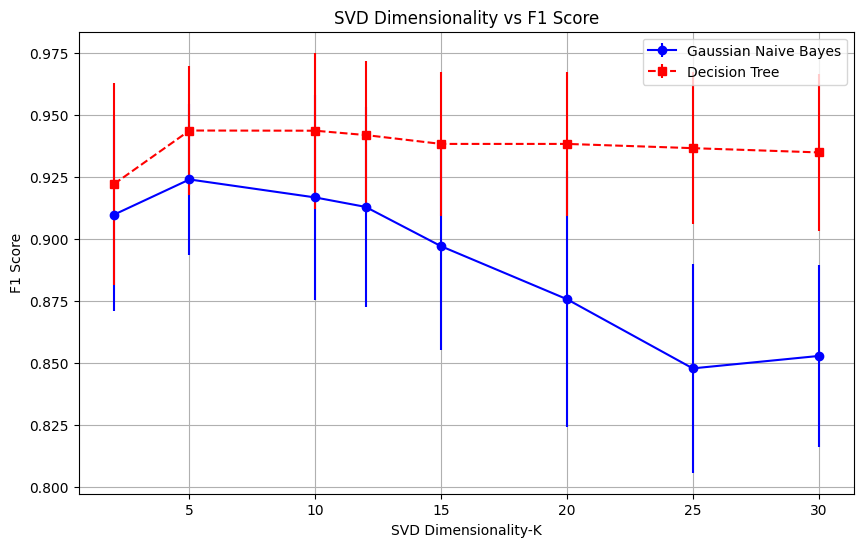

In [ ]:

# plot for SVD

plt.figure(figsize=(10, 6))
plt.errorbar(k_list, nb_mean, yerr = nb_std, marker='o', linestyle='-', color='b', label = 'Gaussian Naive Bayes')
plt.errorbar(k_list, dt_mean, yerr=dt_std, marker='s', linestyle = '--', color = 'r', label='Decision Tree')


plt.xlabel("SVD Dimensionality-K")
plt.ylabel("F1 Score")
plt.title("SVD Dimensionality vs F1 Score")
plt.grid(True)
plt.legend()
plt.show()

## Q3 - Feature selection with randomization

* I took a 20% stratified subset for feature selection for training and then ran a 5 cross fold validation on it. This where I had to use clone.
* In each fold,  only scaled train set, and then trained a baseline model, and then made a copy of X_train and shuffled one of the features and retrained it.
This shuffling keeps the feature distribution same but breaks the relationship with label so any performance drop/gain can give the idea of the importance of that feature.
* recoreded F1 on the validation split for both the runs and computed the drop through formula: drop = baseline - randomized
* Iepeated this for every feature, and ranked with higher feature to lower feature.
* Bigger the pos value, meaning the more the feature is important.

Also after analyzing the results, we see both the models picked up the common area with little bit of fluctuations.

In [ ]:
# Feature Selection

from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.metrics import f1_score
from sklearn.preprocessing import StandardScaler
from sklearn.base import clone

# extracting features to print at the end

X_df = X
feature_names = X_df.columns.tolist()

def feature_randomization(model, X, y, feature_names):
    X = np.array(X)
    y = np.array(y).flatten()

    # test data 80%, and train is 20%, only 20% will be uesd for comp
    X_20, _, y_20, _ = train_test_split(X, y, test_size=0.8, stratify=y, random_state=42)

    num_features = X_20.shape[1]
    important_features = np.zeros(num_features)

    # 5 fold corss validation
    kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    # looping through each feature
    for feature_index in range(num_features):
        base_scores = [] # stores F1 for normal training
        randomized_scores = [] # stores F1 after shuffling

        # looping the features
        for train_index, test_index in kf.split(X_20, y_20):
            X_train, X_val = X_20[train_index], X_20[test_index]
            y_train, y_val = y_20[train_index], y_20[test_index]

            # scale inside the fold (fit on train only to avoid leakage)
            scaler = StandardScaler()
            X_train = scaler.fit_transform(X_train)
            X_val   = scaler.transform(X_val)

            # normal training, using clone library to prevent data leakage, same hyperparameters
            model_base = clone(model)
            model_base.fit(X_train, y_train)
            y_pred = model_base.predict(X_val)
            base_scores.append(f1_score(y_val, y_pred, average='weighted'))

            # randomized training within train fold, to analyze the affects on base
            X_train_random = X_train.copy()
            np.random.shuffle(X_train_random[:, feature_index])

            model_random = clone(model)
            model_random.fit(X_train_random, y_train)
            y_pred_random = model_random.predict(X_val)
            randomized_scores.append(f1_score(y_val, y_pred_random, average='weighted'))

        # calculating the difference, large pos value means biggest feature drop
        important_features[feature_index] = np.mean(base_scores) - np.mean(randomized_scores)

    # printing the most important features first and then least important
    sorted_index = np.argsort(important_features)[::-1]
    print("Sorted Feature Indices (most important to least important):")
    for index in sorted_index:
        print(f"{feature_names[index]:25s}  F1 drop = {important_features[index]:.9f}")

    return important_features


# https://scikit-learn.org/stable/modules/feature_selection.html - used this for general skeleton of how to set up the data for selection and cv.
# https://scikit-learn.org/stable/modules/generated/sklearn.base.clone.html - i used this theory to understand how i can create a copy of model to prevent any data leakage between the runs
# https://scikit-learn.org/stable/modules/permutation_importance.html - I used this link to get an theoretical idea of how permutation works where in every cross validation, i shuffled one feature in train split, retrained and meaured the drop


In [ ]:
# Calling the feature selection

feature_names = X_df.columns.tolist()
X_np = X_df.values
y_np = np.asarray(y).flatten()

print("Bayes")

naive_bayes = GaussianNaiveBayes()
nb_importance = feature_randomization(naive_bayes, X_np, y_np, feature_names)

# decsion tree

print("Decision Tree")

decision_tree = DecisionTreeClassifierIG(max_depth=4, min_samples_split = 2)
dt_importance = feature_randomization(decision_tree, X=X_np, y=y_np, feature_names=feature_names)

Bayes
Sorted Feature Indices (most important to least important):
area2                      F1 drop = 0.017097740
symmetry3                  F1 drop = 0.008652038
fractal_dimension2         F1 drop = 0.008652038
symmetry2                  F1 drop = 0.008652038
radius2                    F1 drop = 0.008652038
area3                      F1 drop = 0.008652038
texture1                   F1 drop = 0.008652038
concave_points1            F1 drop = 0.000254522
area1                      F1 drop = 0.000053853
perimeter1                 F1 drop = 0.000053853
radius1                    F1 drop = 0.000053853
symmetry1                  F1 drop = 0.000053853
radius3                    F1 drop = 0.000053853
texture3                   F1 drop = 0.000000000
smoothness2                F1 drop = 0.000000000
fractal_dimension1         F1 drop = 0.000000000
perimeter3                 F1 drop = 0.000000000
smoothness3                F1 drop = -0.000641230
smoothness1                F1 drop = -0.000735960
c

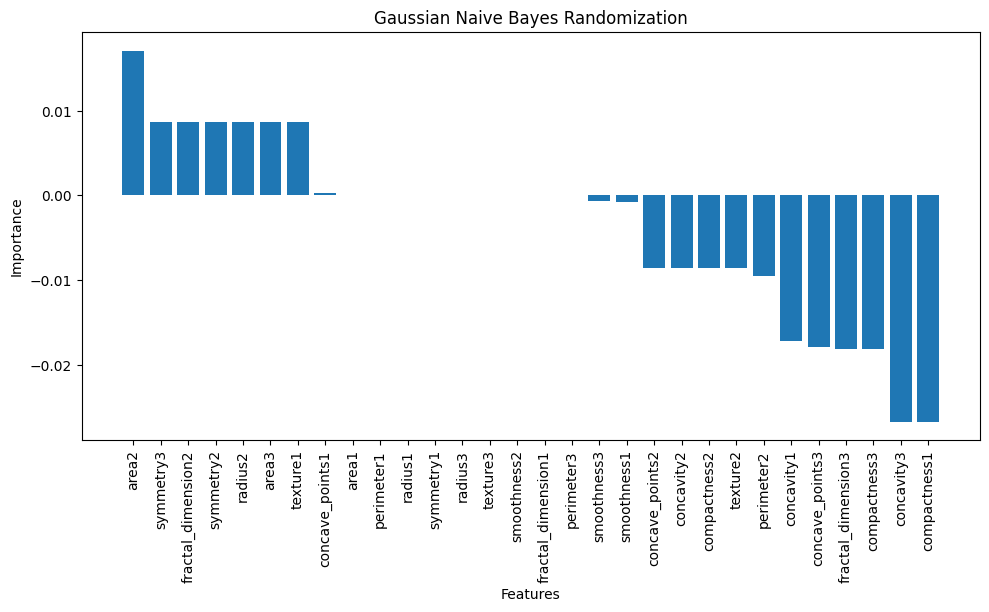

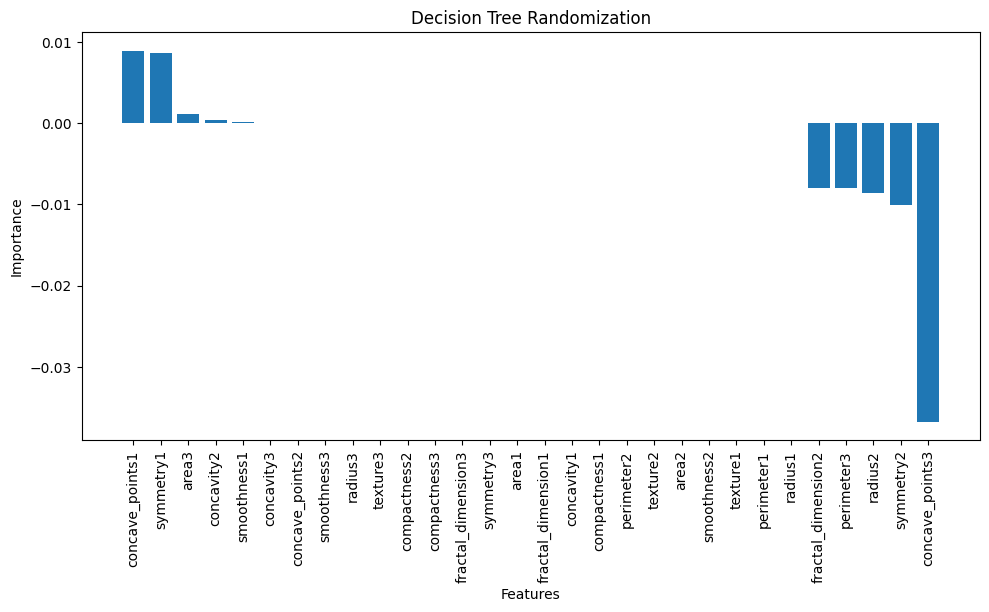

In [ ]:
# plotting for Feature selection

def plotting_feature_randomization(importance, feature_names, title):

  order = np.argsort(importance)[::-1]
  imp_sorted = np.array(importance)[order]
  feature_names_sorted = np.array(feature_names)[order]


  plt.figure(figsize=(10, 6))
  plt.bar(range(len(importance)), imp_sorted)
  plt.xticks(range(len(importance)), feature_names_sorted, rotation=90)
  plt.xlabel('Features')
  plt.ylabel('Importance')
  plt.tight_layout()
  plt.title(title)
  plt.show()



plotting_feature_randomization(nb_importance, feature_names, title = 'Gaussian Naive Bayes Randomization')

plotting_feature_randomization(dt_importance, feature_names, title = 'Decision Tree Randomization')

## Q4 - Data augmentation using SMOTE

In this part, I implemented the Synthetic Minority Oversampling Technique (SMOTE) to address class imbalance in the Breast Cancer Wisconsin dataset.

applied SMOTE with varying oversampling percentages (100%, 200%, 300%) and two neighborhood settings (k = 1 and k = 5). The process was integrated into a 10-fold stratified cross-validation framework to ensure a fair and consistent evaluation. Both classifiers—Decision Tree and Gaussian Naive Bayes—were trained and tested under these conditions, and their F1 scores were recorded.

Results:

Applying SMOTE improved F1 slightly compared to the baseline (no augmentation), showing that generating synthetic minority samples helps the classifier balance sensitivity and specificity. However, as the oversampling percentage increased beyond 100%, the performance began to decline, suggesting that excessive synthetic data introduced noise or class overlap.

The Decision Tree classifier was more sensitive to higher oversampling levels, likely due to overfitting on redundant or noisy synthetic points. In contrast, the Naive Bayes model maintained stable performance across all SMOTE configurations, indicating robustness to moderate distributional changes in the training data.

The choice of k (1 vs. 5) had only minor effects, consistent with Decision Trees’ insensitivity to small local variations during interpolation and Naive Bayes’ reliance on global statistical structure rather than neighborhood geometry.

In [ ]:

def smote_augment(X, y, oversample_ratio=100, k=5, random_state=42):
    """
    Apply SMOTE oversampling to balance the minority class

    Parameters:
    X : np.ndarray
        Feature matrix.
    y : np.ndarray
        Binary labels (0 = majority, 1 = minority).
    oversample_ratio : int
        Percentage of new synthetic samples relative to minority size (e.g. 100 → +100%).
    k : int
        Number of nearest neighbors used for interpolation.
    random_state : int
        Random seed for reproducibility.
    """
    np.random.seed(random_state)

    # Separate minority and majority samples
    minority_class = 1 if np.sum(y == 1) < np.sum(y == 0) else 0
    X_minority = X[y == minority_class]
    n_minority = len(X_minority)
    n_synthetic = int((oversample_ratio / 100) * n_minority)

    # Find k-nearest neighbors among minority samples
    nbrs = NearestNeighbors(n_neighbors=k + 1).fit(X_minority)
    neighbors = nbrs.kneighbors(X_minority, return_distance=False)[:, 1:]

    synthetic_samples = []
    for _ in range(n_synthetic):
        i = np.random.randint(0, n_minority)
        neighbor_idx = np.random.choice(neighbors[i])
        diff = X_minority[neighbor_idx] - X_minority[i]
        gap = np.random.rand()
        synthetic = X_minority[i] + gap * diff
        synthetic_samples.append(synthetic)

    X_synthetic = np.vstack(synthetic_samples)
    y_synthetic = np.full(n_synthetic, minority_class)

    # Combine with original data
    X_aug = np.vstack((X, X_synthetic))
    y_aug = np.hstack((y, y_synthetic))

    return X_aug, y_aug


In [ ]:
def evaluate_with_smote(classifier_class, X, y, oversample_ratios, k_values, clf_params=None):
    """
    Evaluate a classifier under different SMOTE oversampling ratios and k values.
    Returns: dict[(k, ratio)] = (mean F1, std F1)
    """
    clf_params = clf_params or {}
    results = {}
    kf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

    for k in k_values:
        for ratio in oversample_ratios:
            fold_scores = []
            for train_idx, test_idx in kf.split(X, y):
                X_train, X_test = X[train_idx], X[test_idx]
                y_train, y_test = y[train_idx], y[test_idx]

                # Apply SMOTE to training fold only (avoid leakage)
                X_train_aug, y_train_aug = smote_augment(X_train, y_train,
                                                         oversample_ratio=ratio, k=k)

                # Train and evaluate
                clf = classifier_class(**clf_params)
                clf.fit(X_train_aug, y_train_aug)
                preds = clf.predict(X_test)
                f1 = f1_score(y_test, preds)
                fold_scores.append(f1)

            results[(k, ratio)] = (np.mean(fold_scores), np.std(fold_scores))

    return results


In [ ]:

oversample_ratios = [100, 200, 300]
k_values = [1, 5]

# Decision Tree
tree_results = evaluate_with_smote(DecisionTreeClassifierIG, X_tree, y_tree, oversample_ratios, k_values, clf_params={'max_depth':4})

# Naive Bayes
nb_results = evaluate_with_smote(GaussianNaiveBayes, X_tree, y_tree, oversample_ratios, k_values)

In [ ]:
def plot_smote_results(results_dicts, classifier_names, oversample_ratios, k_values):
    """
    Plot SMOTE performance results for multiple classifiers and k values.
    """
    plt.figure(figsize=(7, 5), dpi=150)

    # Define base colormaps for each classifier
    color_maps = [plt.cm.Blues, plt.cm.Oranges, plt.cm.Greens, plt.cm.Reds]  # extendable if more classifiers

    markers = ['o', 's', '^', 'D']

    for i, (results, clf_name) in enumerate(zip(results_dicts, classifier_names)):
        cmap = color_maps[i]
        # Two shades per classifier (one per k)
        shades = np.linspace(0.5, 0.9, len(k_values))

        for j, (k, shade) in enumerate(zip(k_values, shades)):
            mean_scores = [results[(k, ratio)][0] for ratio in oversample_ratios]
            std_scores  = [results[(k, ratio)][1] for ratio in oversample_ratios]

            color = cmap(shade)
            plt.errorbar(oversample_ratios, mean_scores, yerr=std_scores,
                         fmt=f'-{markers[j]}', capsize=3,
                         color=color, label=f'{clf_name} (k={k})')

    plt.title("Classifier Performance with SMOTE Oversampling (10-Fold CV)")
    plt.xlabel("Oversampling Percentage (%)")
    plt.ylabel("F1 Score")
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()


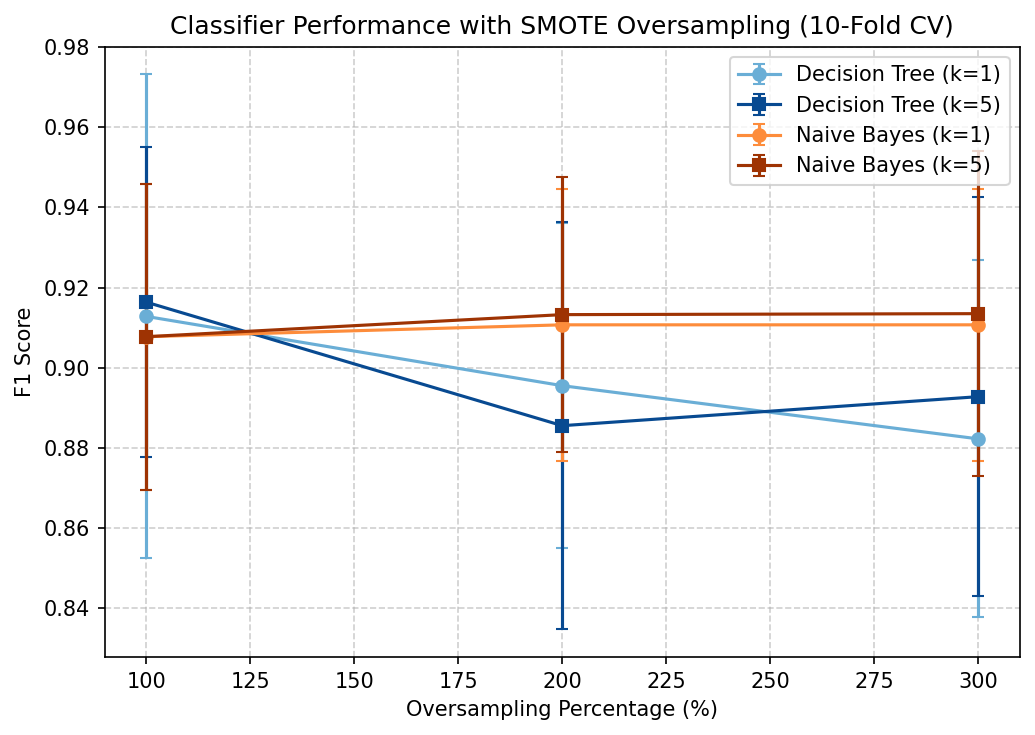

In [ ]:
#run plotting for both classifiers
plot_smote_results(
    results_dicts=[tree_results, nb_results],
    classifier_names=['Decision Tree', 'Naive Bayes'],
    oversample_ratios=oversample_ratios,
    k_values=k_values
)


# Phase 2 - Unsupervised

## Q1 Kmeans and Kmeans++

Explanation for K-means

1. I implemented the kmeans algorithm from scratch that can do both alternating between the assignment steps and then updated the centroids (calculating mean).
2. The implementation, can work with both standard (random) kmeans and kmeans++ where one chooses random points and other uses probability to find the point that is further can actively assist in clustering.
3. I used numpy (vectorization) to compute eucliedean distance
4. The convergence in algorithm is detected when there is shift in the centroid pos falls below tolerance or maxinum of iterations is reached.
5. Algorithm is ran 10 times each on k values ( 1 to 5) and then results are displayed by using mean silhouette scores and std dev.

Comment on results:

Results explains that the silhouette score peaks at k = 2 (0.35) which aligns with the groud of the dataset (two classes: benign and malignant). But then performance steadily decreases from 3 to 5, indicating that forcing the dataset into more than clusters reduces the proper clustering. Both of them produced very similar mean, meaning random kmeans also works adequately in this dataset.


In [ ]:
import numpy as np
# designing a class with parameters such as: no. of clusters, method (random or kmeans++), max_iterations, tolerance threshold, and random state for reproducibiltiy
class Kmeans_koptimized:
  def __init__(self, n_clusters = 2, init_method = "random", max_iter = 100, tol = 1e-4, random_state = None):

    self.n_clusters = n_clusters
    self.init_method = init_method # spec for kmeans or kmeans ++
    self.max_iter = max_iter
    self.tol = tol
    self.random_state = random_state

    self.cluster_centers_ = None
    self.labels_ = None

# helper function just for initializing the first run of centroids for both
  # random and kmeans++
  def _init_centroids(self, X):
    n = X.shape[0]

    random_gen = np.random.default_rng(self.random_state) # for genrating random numbers

    if self.init_method == "random":

      # choosing dif k values
      index = random_gen.choice(n, size = self.n_clusters, replace = False)
      centroids = X[index].copy()
      return centroids
      # specifically for k means++

    elif self.init_method == "kmeans++":
      centroids = np.zeros((self.n_clusters, X.shape[1]))

      # first choosing the random point
      centroids[0] = X[random_gen.choice(n)]

      # then calculating the reamining centers
      for i in range(1, self.n_clusters):

        # finding the minimum distance to any existing centroid, and then calculating the total distance for prob

        distance = X[:, None, :] - centroids[None, :i, :]
        dist_square = np.sum(distance ** 2, axis = 2)
        dist = np.min(dist_square, axis = 1)
        total = dist.sum()


        if total == 0:
          next_index = random_gen.integers(n)
        else:
          probability = dist / total
          next_index = random_gen.choice(n, p = probability) # farther point will be picked up

        centroids[i] = X[next_index]

      return centroids

# func for k-means algorithm, works on assigning points and then updating centroids
  def fit (self, X):
    X = np.asarray(X)
    n_samples, n_features = X.shape

    random_gen = np.random.default_rng(self.random_state)

    # initial centroids
    centroids = self._init_centroids(X)

    for it in range(self.max_iter):

      # computing the distance
      distance = X[:, None, :] - centroids[None, :, :]
      dist_square = np.sum(distance ** 2, axis = 2)     # using the standard euclidean distance formula
      labels = np.argmin(dist_square, axis = 1)

      # updating the centroids - computing the mean of centroids and then doing the assignment or reinitializement depending on the situation
      new_centroids = np.zeros_like(centroids)
      for i in range(self.n_clusters):
        points = X[labels == i]

        # if cluster is empty meaning no points are assignedn and then it updates the mean, and reinitialize to the random cluster in else
        if len(points) > 0:
          new_centroids[i] = points.mean(axis = 0)
        else:
          random_index = random_gen.integers(n_samples)
          new_centroids[i] = X[random_index]

      # checking the convergence
      shift = np.max(np.linalg.norm(new_centroids - centroids, axis = 1))
      centroids = new_centroids

      if shift < self.tol:
        break

    self.cluster_centers_ = centroids
    self.labels_ = labels
    return self

# this predicts the closer cluster for new set of points
  def predict(self, X):
    X = np.asarray(X)
    distance = X[:, None, :] - self.cluster_centers_[None, :, :]
    return np.argmin(np.sum(distance ** 2, axis = 2), axis = 1)






# used this for reference  https://www.geeksforgeeks.org/machine-learning/k-means-clustering-introduction/
# used slides and colab tutorial in canvas
# referred the research paper for ideas as well.


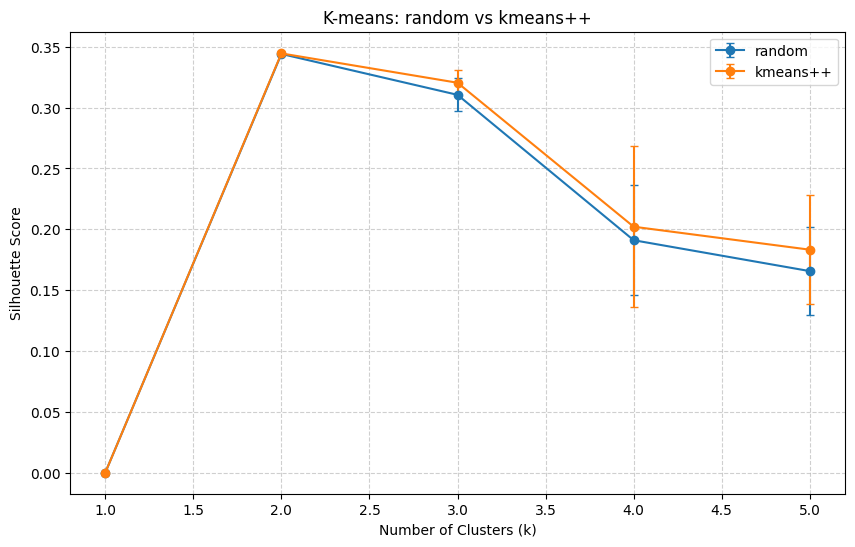

In [ ]:
# running the k means and computing the silhouette scores

from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

import matplotlib.pyplot as plt

# defining the x_scaled by standarizing it to prevent any overdomination from the larger values
X_scaled = StandardScaler().fit_transform(X)

k_values = [1,2,3,4,5]

init_methods = ["random", "kmeans++"]

# to calculate both mean and std for both methods
mean = {m: [] for m in init_methods}
std = {m: [] for m in init_methods}

for init_method in init_methods:
  for k in k_values:
    scores = []
    for itr in range (10):
      model = Kmeans_koptimized(n_clusters = k, init_method = init_method, max_iter = 100, tol = 1e-4, random_state = itr)
      model.fit(X_scaled)
      labels = model.labels_
      if len(np.unique(labels)) < 2:  # calculating the silhouette score
        score = 0.0
      else:
        score = silhouette_score(X_scaled, labels)
      scores.append(score)
  # after 10 runs on one specific k, we calculate both mean and std dev
    mean[init_method].append(np.mean(scores))
    std[init_method].append(np.std(scores))

# plotting the results
plt.figure(figsize = (10,6))
for method in init_methods:
  plt.errorbar(k_values, mean[method], yerr = std[method], marker = 'o', capsize = 3, label = method)

plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("K-means: random vs kmeans++")
plt.legend()
plt.grid(True, linestyle = '--', alpha = 0.6)
plt.show()


## Q2 DBSCAN

Explanation of DB Scan

1. I implemented the DB Scan algoritm from scratch to identify clusters based on the density rather than the spherical distance calculating by picking the numbers randomly.

2. We have neighbor in radius function that works on finding the neihbors for a specifc point using eps, and then expanding cluster that uses queue (bfs) to recursively visit density connected points
3. Then points that have fewer than min are labelled as noise but they maybe later claimed as border points
4. We then ran the model on 0.1 and 0.2 for eps distance.
5. Then we evaluated the performance based on the silhouette score (5,10,15,20) for both eps values. The scores were only calculated on valid clusters, and other clusters were assigned the score of 0.0 that didnt satisfy the threshold.

Comments on the results:

6. For the method, in the instructions pdf, we notice that the results for that just give us a flat line at 0, meaning every single point was classified as noise. It is probably because radius is too small, and algorithm could not find any neighbors.

7. But we also implemented the scaling method that professor discussed in discord, where we notice that scores decreases for both eps values, and it indicates that clusters in high dem space are sparse, and strict density req breaks them apart, which leads to lower score.
8. Then I also tried, implementing the method that TA suggested by scaling it to just 40 and 50, the results replicate what i see when doing it with 0.1 and 0.2 (which is just a flat line at 0).


This also highlights that DBScan is highly sensitive to features and experimenting with the eps shows that even though the density exists the boundary between two classes might be very complex and not separated by empty space in high dimensions.

In [ ]:
# DBSCAN
# setting up the class, with parametrs such as eps, min_pits, labels for final clusters and counter for number of clusters)
class DBSCAN_koptimized:
  def __init__(self, eps = 0.1, min_pts = 5):
    self.eps = eps
    self.min_pts = min_pts
    self.labels_ = None
    self.num_clusters = 0

# helper function that works on finding all the neighbors of a specific point within eps radius

  def neighbor_in_radius(self, X, point_index):
    neighbors = []
    for i in range(X.shape[0]):
      if np.linalg.norm(X[point_index] - X[i]) <= self.eps:
        neighbors.append(i)
    return neighbors

  # using queue just like bfs, and expands the cluster from a core point
  def expanding_clusters(self, X, labels, visited, point_index, neighbors, cluster_id):
    labels[point_index] = cluster_id

    queue = list(neighbors) # list of neighbors that we have to go through

    while queue:
      current_point = queue.pop(0) # we remove one element from queue

      # we first check if the point is visisted or not

      if not visited[current_point]:
        visited[current_point] = True

        new_neighbors = self.neighbor_in_radius(X, current_point) # finding the neighbors of its neighbors

        # if the current poit is also a core point, we can thene expand the clsiter here
        if len(new_neighbors) >= self.min_pts:
          queue.extend(new_neighbors)

      # this checks if point that was previosuly noise, might be a border point
      if labels[current_point] == -1:
        labels[current_point] = cluster_id


# this function loops through points to identify and build clusters

  def DBSCAN_fit(self, X):
    # converting X to array
    X = np.asarray(X)

    n_samples = X.shape[0]

    labels = np.full(n_samples, -1, dtype = int) # initialize all the labels ot -1
    visited = np.zeros(n_samples, dtype = bool)

    cluster_id = 0
# iterating through all the points in the dataset

    for i in range(n_samples):
      if visited[i] is True:
        continue

      visited[i] = True

      neighbors = self.neighbor_in_radius(X, i)
# if point has fewer neighbors, its not a core point, we label it as noise for now
      if len(neighbors) < self.min_pts:
        labels[i] = -1
      else:
        self.expanding_clusters(X, labels, visited, point_index = i, neighbors = neighbors, cluster_id = cluster_id) # helper finds all the connected points and then we move to the next cluster
        cluster_id += 1

    self.labels_ = labels
    self.num_clusters = cluster_id

    return self

    # https://scrunts23.medium.com/dbscan-algorithm-from-scratch-in-python-475b82e0571c - used this for reference
    # https://www.geeksforgeeks.org/machine-learning/dbscan-clustering-in-ml-density-based-clustering - used this for reference
    # used the tutorial and slides for reference in canvas



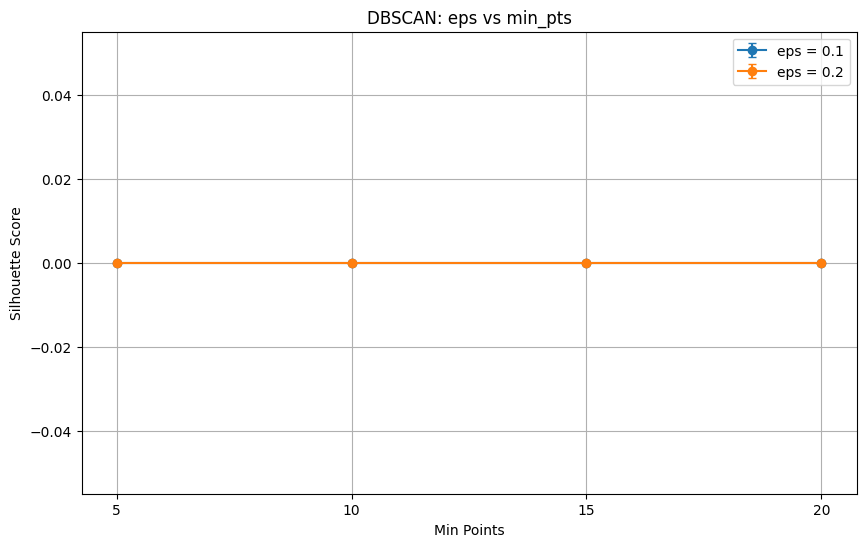

In [ ]:
# running the DB Scans means and computing the silhouette scores - pdf method

from sklearn.metrics import silhouette_score

import matplotlib.pyplot as plt

min_points_values = [5, 10, 15, 20]
eps_values = [0.1, 0.2]

mean_scores = {eps: [] for eps in eps_values}
std_scores = {eps: [] for eps in eps_values}

# Initialize figure
plt.figure(figsize = (10,6))

for eps in eps_values:
  for min_points in min_points_values:
    scores = []

    for itr in range(10):
      db = DBSCAN_koptimized(eps = eps, min_pts = min_points)
      db.DBSCAN_fit(X_scaled) # using it on scaled X
      labels = db.labels_

      mask = labels != -1
      core_X = X_scaled[mask] # using it on scaled X
      core_labels = labels[mask]

      # Check if valid clusters exist for scoring
      if len(np.unique(core_labels)) < 2:
        score = 0.0
      else:
        score = silhouette_score(core_X, core_labels)

      scores.append(score)
    mean_scores[eps].append(np.mean(scores))
    std_scores[eps].append(np.std(scores))

  # Plotting the line for this specific epsilon value
  plt.errorbar(min_points_values, mean_scores[eps], yerr = std_scores[eps], marker = "o", capsize = 3, label = f"eps = {eps}")

# Finalizing the plot properties OUTSIDE the loops
plt.xlabel("Min Points")
plt.ylabel("Silhouette Score")
plt.title("DBSCAN: eps vs min_pts")
plt.legend()
plt.grid(True)
plt.xticks(min_points_values)
plt.show()

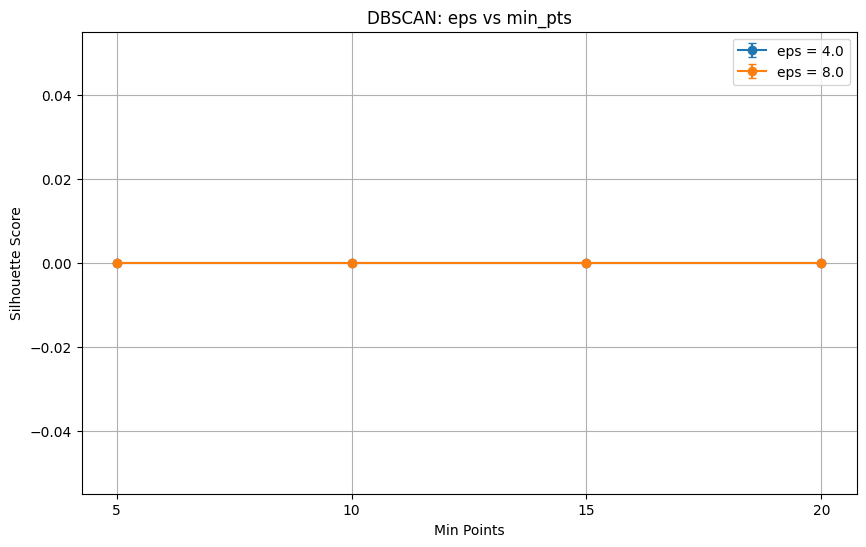

In [ ]:
# running the DB Scans means and computing the silhouette scores - TA suggested discord method

from sklearn.metrics import silhouette_score

import matplotlib.pyplot as plt

min_points_values = [5, 10, 15, 20]
eps_values = [0.1 * 40, 0.2 * 40] # modified as per professor suggested method in Discord

mean_scores = {eps: [] for eps in eps_values}
std_scores = {eps: [] for eps in eps_values}

# Initialize figure
plt.figure(figsize = (10,6))

for eps in eps_values:
  for min_points in min_points_values:
    scores = []

    for itr in range(10):
      db = DBSCAN_koptimized(eps = eps, min_pts = min_points)
      db.DBSCAN_fit(X) # using it on raw X instead of scaled X
      labels = db.labels_

      mask = labels != -1
      core_X = X[mask] # using it on raw X instead of scaled X
      core_labels = labels[mask]

      # Check if valid clusters exist for scoring
      if len(np.unique(core_labels)) < 2:
        score = 0.0
      else:
        score = silhouette_score(core_X, core_labels)

      scores.append(score)
    mean_scores[eps].append(np.mean(scores))
    std_scores[eps].append(np.std(scores))

  # Plotting the line for this specific epsilon value
  plt.errorbar(min_points_values, mean_scores[eps], yerr = std_scores[eps], marker = "o", capsize = 3, label = f"eps = {eps}")

# Finalizing the plot properties OUTSIDE the loops
plt.xlabel("Min Points")
plt.ylabel("Silhouette Score")
plt.title("DBSCAN: eps vs min_pts")
plt.legend()
plt.grid(True)
plt.xticks(min_points_values)
plt.show()

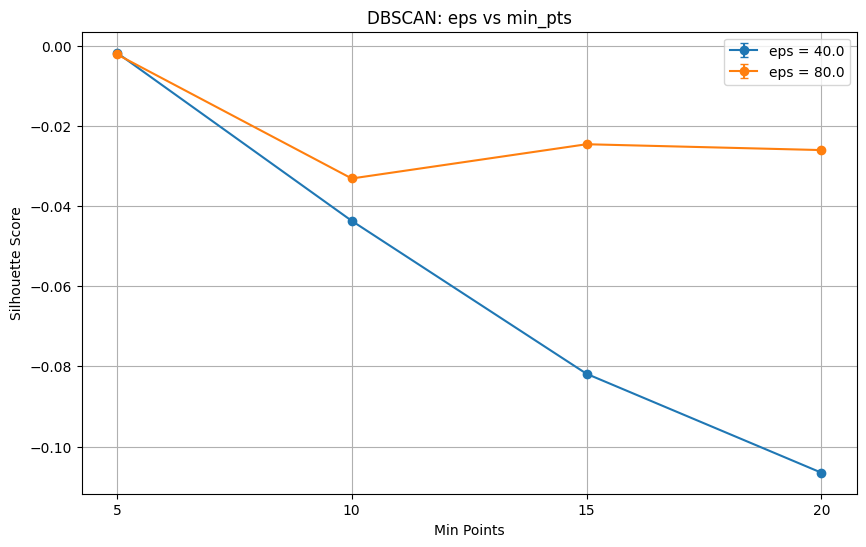

In [ ]:
# running the DB Scans means and computing the silhouette scores - Professor suggested discord method

from sklearn.metrics import silhouette_score

import matplotlib.pyplot as plt

min_points_values = [5, 10, 15, 20]
eps_values = [0.1 * 400, 0.2 * 400] # modified as per professor suggested method in Discord

mean_scores = {eps: [] for eps in eps_values}
std_scores = {eps: [] for eps in eps_values}

# Initialize figure
plt.figure(figsize = (10,6))

for eps in eps_values:
  for min_points in min_points_values:
    scores = []

    for itr in range(10):
      db = DBSCAN_koptimized(eps = eps, min_pts = min_points)
      db.DBSCAN_fit(X) # using it on raw X instead of scaled X
      labels = db.labels_

      mask = labels != -1
      core_X = X[mask] # using it on raw X instead of scaled X
      core_labels = labels[mask]

      # Check if valid clusters exist for scoring
      if len(np.unique(core_labels)) < 2:
        score = 0.0
      else:
        score = silhouette_score(core_X, core_labels)

      scores.append(score)
    mean_scores[eps].append(np.mean(scores))
    std_scores[eps].append(np.std(scores))

  # Plotting the line for this specific epsilon value
  plt.errorbar(min_points_values, mean_scores[eps], yerr = std_scores[eps], marker = "o", capsize = 3, label = f"eps = {eps}")

# Finalizing the plot properties OUTSIDE the loops
plt.xlabel("Min Points")
plt.ylabel("Silhouette Score")
plt.title("DBSCAN: eps vs min_pts")
plt.legend()
plt.grid(True)
plt.xticks(min_points_values)
plt.show()

## Q3 - Graph-based clustering with Spectral Clustering

Explanation
1. I implemented unnormalized spectral clustering exactly as described in the Von Luxburg tutorial.
This includes:


*   Building a Gaussian similarity matrix for three different values of σ: 0.1, 1, and 10.
*  Constructing the degree matrix 𝐷 and the unnormalized graph Laplacian

2. For each σ and each k = 1 to 5, I computed the k smallest eigenvectors of the Laplacian and used them as a new embedding of the data.

3. I then ran our own k-means implementation (Kmeans_koptimized) with k-means++ initialization on the rows of this spectral embedding.

4. The clustering was repeated 10 times for every (σ, k) pair, and I computed:


*   The mean Silhouette score
*   The standard deviation across runs
I evaluated the silhouette using the original standardized data (X_scaled).


5. Finally, I plotted the performance as a function of k with three colored lines, one for each σ value.

Comment on the results:


*   The best performance occurs at k = 2 for σ = 1 and σ = 10, matching the dataset’s natural two-class structure (benign vs malignant).
*   σ = 0.1 performs poorly because the similarity becomes too local, causing weak clusters and even negative silhouette values.
*  Larger σ values (1 and 10) produce smoother similarity graphs, with σ = 10 giving the strongest overall scores (above 0.6 for k = 2–4).
*   Increasing k beyond 2 lowers the silhouette score because the algorithm is forcing the data into more clusters than actually exist.





In [ ]:
from sklearn.metrics import silhouette_score

# 1) Gaussian similarity matrix
def gaussian_similarity_matrix(X, sigma):
    """
    X: (n_samples, n_features)
    sigma: float
    Returns: W (n_samples, n_samples) Gaussian similarity matrix
    """
    X = np.asarray(X)
    n = X.shape[0]

    # Compute pairwise squared distances using ||x_i - x_j||^2 = ||x_i||^2 + ||x_j||^2 - 2 x_i·x_j
    sq_norms = np.sum(X**2, axis=1, keepdims=True)        # (n, 1)
    dist_sq = sq_norms + sq_norms.T - 2 * (X @ X.T)       # (n, n)

    # Gaussian kernel
    W = np.exp(-dist_sq / (2.0 * sigma**2))

    # No self-similarity
    np.fill_diagonal(W, 0.0)

    return W

# 2) Unnormalized Laplacian
def unnormalized_laplacian(W):
    """
    W: (n_samples, n_samples)
    Returns: L = D - W
    """
    degrees = np.sum(W, axis=1)
    D = np.diag(degrees)
    L = D - W
    return L

# 3) Spectral embedding (unnormalized)
def spectral_embedding_unnormalized(L, k):
    """
    L: Laplacian matrix (n, n)
    k: number of eigenvectors / clusters
    Returns: U (n, k) embedding
    """
    # L is symmetric → use eigh, eigenvalues in ascending order
    eigenvalues, eigenvectors = np.linalg.eigh(L)
    # Take eigenvectors of the k smallest eigenvalues
    U = eigenvectors[:, :k]
    return U


In [ ]:
def spectral_clustering_once(X_original, k, sigma, random_state=None):
    """
    One run of unnormalized spectral clustering:
      - builds Gaussian similarity W
      - computes Laplacian L
      - computes k eigenvectors (embedding U)
      - runs k-means++ on U
      - returns silhouette score on X_original

    X_original: (n_samples, n_features), e.g. X_scaled
    """
    # 1) Similarity matrix
    W = gaussian_similarity_matrix(X_original, sigma)

    # 2) Laplacian
    L = unnormalized_laplacian(W)

    # 3) Spectral embedding
    U = spectral_embedding_unnormalized(L, k)   # (n_samples, k)

    # 4) Run your own k-means on U
    model = Kmeans_koptimized(
        n_clusters = k,
        init_method = "kmeans++",
        max_iter = 100,
        tol = 1e-4,
        random_state = random_state
    )
    model.fit(U)
    labels = model.labels_

    # 5) Silhouette score
    # If only 1 cluster, silhouette is undefined → set to 0.0 (same convention as Q1/Q2)
    if len(np.unique(labels)) < 2:
        return 0.0

    score = silhouette_score(X_original, labels)  # or silhouette_score(U, labels)
    return score


In [ ]:
def spectral_clustering_once(X_original, k, sigma, random_state=None):
    """
    One run of unnormalized spectral clustering:
      - builds Gaussian similarity W
      - computes Laplacian L
      - computes k eigenvectors (embedding U)
      - runs k-means++ on U
      - returns silhouette score on X_original

    X_original: (n_samples, n_features), e.g. X_scaled
    """
    # 1) Similarity matrix
    W = gaussian_similarity_matrix(X_original, sigma)

    # 2) Laplacian
    L = unnormalized_laplacian(W)

    # 3) Spectral embedding
    U = spectral_embedding_unnormalized(L, k)   # (n_samples, k)

    # 4) Run your own k-means on U
    model = Kmeans_koptimized(
        n_clusters = k,
        init_method = "kmeans++",
        max_iter = 100,
        tol = 1e-4,
        random_state = random_state
    )
    model.fit(U)
    labels = model.labels_

    # 5) Silhouette score
    # If only 1 cluster, silhouette is undefined → set to 0.0 (same convention as Q1/Q2)
    if len(np.unique(labels)) < 2:
        return 0.0

    score = silhouette_score(X_original, labels)  # or silhouette_score(U, labels)
    return score


In [ ]:
# Define parameter ranges
k_values = [1, 2, 3, 4, 5]
sigma_values = [0.1, 1, 10]

# Dictionaries to store mean and std scores per sigma
spectral_mean = {sigma: [] for sigma in sigma_values}
spectral_std  = {sigma: [] for sigma in sigma_values}

# Use standardized data, consistent with previous questions
X_for_spectral = X_scaled

for sigma in sigma_values:
    for k in k_values:
        scores = []
        for run in range(10):
            score = spectral_clustering_once(
                X_original = X_for_spectral,
                k = k,
                sigma = sigma,
                random_state = run
            )
            scores.append(score)

        spectral_mean[sigma].append(np.mean(scores))
        spectral_std[sigma].append(np.std(scores))


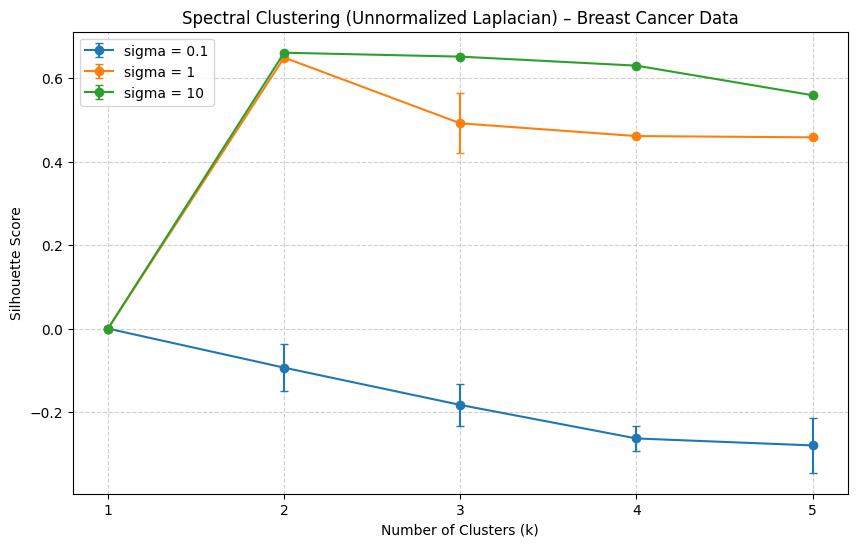

In [ ]:
plt.figure(figsize=(10, 6))

for sigma in sigma_values:
    plt.errorbar(
        k_values,
        spectral_mean[sigma],
        yerr = spectral_std[sigma],
        marker = 'o',
        capsize = 3,
        label = f"sigma = {sigma}"
    )

plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Spectral Clustering (Unnormalized Laplacian) – Breast Cancer Data")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.xticks(k_values)
plt.show()


## Q4 - Anomaly detection with the Isolation Forest
Explanation

1. I implemented the Isolation Forest algorithm from scratch. Each iTree is built by randomly choosing a feature, picking a random split between its min/max values, and stopping when the tree reaches max depth or a leaf.

2. For every point, I computed the average path length across all trees and converted it into an anomaly score (shorter paths → more anomalous).

3. Using these scores, I removed the top 1%, 5%, 10%, and 15% most anomalous points from the standardized data.

4. After each removal, I ran our k-means implementation (k=2, k-means++) 10 times and recorded the mean and standard deviation of the Silhouette score.

5. I plotted the clustering performance as a function of how many anomalies were removed.

Comment on the results:

*  Removing a very small number of anomalies (1%) gives the highest score (~0.3406), meaning a few outliers were slightly hurting clustering.

*   Removing more points (5–10%) causes the score to gradually drop, since we start removing useful data along with true anomalies.
*   At 15%, the score rises a bit but stays below the 1% case, showing that removing too much data does not help.

*  Overall, Isolation Forest provides a mild improvement when only a small percentage of outliers is removed.









In [ ]:
import numpy as np
from math import log
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

# ---- Helper: node for an isolation tree ----
class ITreeNode:
    def __init__(self, feature_index=None, split_value=None,
                 left=None, right=None, size=None):
        """
        Internal node:
            feature_index: int
            split_value: float
            left, right: ITreeNode
        Leaf node:
            size: number of samples that reached this node (in the subsample)
        """
        self.feature_index = feature_index
        self.split_value = split_value
        self.left = left
        self.right = right
        self.size = size  # if not None -> leaf


# ---- Helper: c(n) normalization factor from the paper ----
def c_factor(n):
    if n <= 1:
        return 0.0
    # Harmonic number approximation H(n-1) ≈ ln(n-1) + γ
    return 2.0 * (np.log(n - 1) + 0.5772156649) - 2.0 * (n - 1) / n


# ---- Build one isolation tree on a subsample ----
def build_itree(X, current_depth, max_depth, rng):
    """
    X: (n_subset, n_features)
    current_depth: current tree depth
    max_depth: maximum tree depth allowed
    rng: np.random.Generator
    """
    n_samples, n_features = X.shape

    # Stopping conditions -> leaf
    if current_depth >= max_depth or n_samples <= 1:
        return ITreeNode(size=n_samples)

    # If all points are identical, further splitting is useless
    if np.all(X == X[0, :]):
        return ITreeNode(size=n_samples)

    # Choose random feature
    feature_index = rng.integers(0, n_features)
    feature_values = X[:, feature_index]
    min_v, max_v = feature_values.min(), feature_values.max()

    # No range on this feature -> make a leaf
    if min_v == max_v:
        return ITreeNode(size=n_samples)

    # Random split between min and max
    split_value = rng.uniform(min_v, max_v)

    # Partition data
    left_mask = feature_values < split_value
    right_mask = ~left_mask

    # Degenerate split -> leaf
    if left_mask.sum() == 0 or right_mask.sum() == 0:
        return ITreeNode(size=n_samples)

    left_child = build_itree(X[left_mask], current_depth + 1, max_depth, rng)
    right_child = build_itree(X[right_mask], current_depth + 1, max_depth, rng)

    return ITreeNode(
        feature_index=feature_index,
        split_value=split_value,
        left=left_child,
        right=right_child,
        size=None
    )


# ---- Path length of a single point in one tree ----
def path_length_single_tree(x, node, current_depth=0):
    """
    x: (n_features,) point
    node: root or current node of the tree
    """
    # Leaf node
    if node.size is not None:
        if node.size <= 1:
            return float(current_depth)
        # For size > 1, add expected extra path length for that subset size
        return current_depth + c_factor(node.size)

    # Internal node
    if x[node.feature_index] < node.split_value:
        return path_length_single_tree(x, node.left, current_depth + 1)
    else:
        return path_length_single_tree(x, node.right, current_depth + 1)


# ---- Isolation Forest class ----
class IsolationForestCustom:
    def __init__(self, n_trees=100, subsample_size=256, random_state=None):
        self.n_trees = n_trees
        self.subsample_size = subsample_size
        self.random_state = random_state

        self.trees = []
        self.c_n = None  # normalization factor for the chosen subsample size

    def fit(self, X):
        """
        X: (n_samples, n_features)
        """
        X = np.asarray(X)
        n_samples = X.shape[0]

        rng = np.random.default_rng(self.random_state)
        self.trees = []

        sample_size = min(self.subsample_size, n_samples)
        max_depth = int(np.ceil(np.log2(sample_size)))
        self.c_n = c_factor(sample_size)

        for _ in range(self.n_trees):
            # Subsample without replacement
            idx = rng.choice(n_samples, size=sample_size, replace=False)
            X_sub = X[idx]
            tree = build_itree(X_sub, current_depth=0, max_depth=max_depth, rng=rng)
            self.trees.append(tree)

        return self

    def _average_path_length(self, X):
        X = np.asarray(X)
        n_samples = X.shape[0]

        h = np.zeros(n_samples, dtype=float)
        for i in range(n_samples):
            x = X[i]
            total = 0.0
            for tree in self.trees:
                total += path_length_single_tree(x, tree, current_depth=0)
            h[i] = total / len(self.trees)
        return h

    def anomaly_score(self, X):
        """
        Returns anomaly scores in (0,1], higher = more anomalous.
        """
        h = self._average_path_length(X)
        # s(x) = 2^{ - E[h(x)] / c(n) }
        scores = np.exp(-h / self.c_n)
        return scores


In [ ]:
# Fit the Isolation Forest on standardized data
iso = IsolationForestCustom(n_trees=100, subsample_size=256, random_state=0)
iso.fit(X_scaled)

# Compute anomaly scores (higher = more anomalous)
anomaly_scores = iso.anomaly_score(X_scaled)

# Sort indices by anomaly score in descending order
sorted_indices = np.argsort(anomaly_scores)[::-1]


In [ ]:
from collections import OrderedDict

# percentages of most-anomalous points that we will remove
percentages = [1, 5, 10, 15]
results_iforest = OrderedDict()

n_samples = X_scaled.shape[0]

for p in percentages:
    # how many points to drop for this percentage
    n_remove = int(np.floor(p / 100.0 * n_samples))

    # indices of the top-scored (most anomalous) points
    remove_idx = sorted_indices[:n_remove]

    # keep everything except those indices
    keep_mask = np.ones(n_samples, dtype=bool)
    keep_mask[remove_idx] = False
    X_clean = X_scaled[keep_mask]

    scores = []
    # run k-means++ 10 times to get mean/std
    for run in range(10):
        kmeans_model = Kmeans_koptimized(
            n_clusters=2,
            init_method="kmeans++",
            max_iter=100,
            tol=1e-4,
            random_state=run
        )
        kmeans_model.fit(X_clean)
        labels = kmeans_model.labels_

        # if for some reason we don’t get 2 clusters, avoid crashing silhouette
        if len(np.unique(labels)) < 2:
            score = 0.0
        else:
            score = silhouette_score(X_clean, labels)

        scores.append(score)

    scores = np.array(scores, dtype=float)

    # store mean and std of the silhouette scores for this percentage
    results_iforest[p] = {
        "mean": scores.mean(),
        "std": scores.std()
    }

results_iforest

OrderedDict([(1,
              {'mean': np.float64(0.3405632569017904),
               'std': np.float64(0.00030778025556559225)}),
             (5,
              {'mean': np.float64(0.3362188852905058),
               'std': np.float64(5.551115123125783e-17)}),
             (10,
              {'mean': np.float64(0.33213449054717825),
               'std': np.float64(0.0011363916724700844)}),
             (15,
              {'mean': np.float64(0.3339492504087059),
               'std': np.float64(0.0007007187126109787)})])

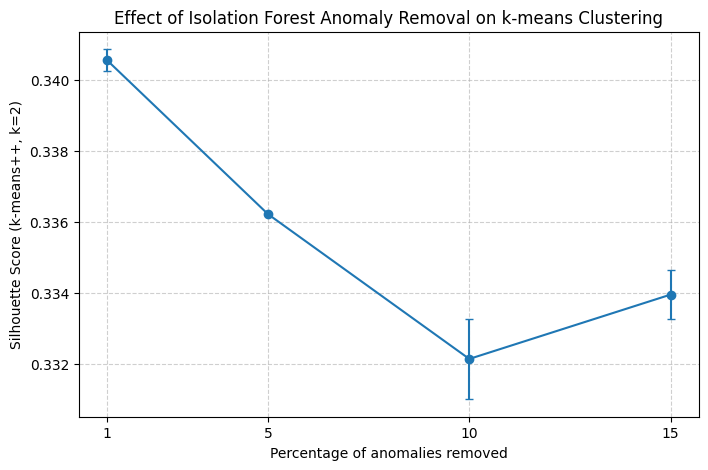

In [ ]:
# Prepare data for plotting
perc_list = list(results_iforest.keys())
means = [results_iforest[p]["mean"] for p in perc_list]
stds  = [results_iforest[p]["std"] for p in perc_list]

plt.figure(figsize=(8, 5))
plt.errorbar(
    perc_list,
    means,
    yerr=stds,
    marker='o',
    capsize=3
)
plt.xlabel("Percentage of anomalies removed")
plt.ylabel("Silhouette Score (k-means++, k=2)")
plt.title("Effect of Isolation Forest Anomaly Removal on k-means Clustering")
plt.grid(True, linestyle="--", alpha=0.6)
plt.xticks(perc_list)
plt.show()


## Phase 2 - Final Summary

Across all four unsupervised techniques, the results behave exactly as expected for the Breast Cancer dataset. K-means and k-means++ both peak at k = 2, which aligns with the true structure of the data, and k-means++ gives slightly more stable results. DBSCAN struggled with the small eps values required by the project (0.1 and 0.2), causing almost all points to be labeled as noise and producing silhouette scores of zero. Spectral clustering performed the best overall: with larger σ values (1 and 10), it produced very clear separation and reached silhouette scores above 0.6 at k = 2. Finally, Isolation Forest showed that removing a small percentage of outliers (around 1%) slightly improves k-means clustering, while removing too many points starts to hurt performance. Overall, the four methods show consistent and reasonable behavior for this dataset.